In [1]:
# Import ESM classes from HF transformers
from transformers import AutoModel, AutoTokenizer, EsmTokenizer, EsmForMaskedLM, AutoTokenizer
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from pathlib import Path
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt
import itertools
import time
import numpy as np
import gc
import json


In [14]:

pdbs = ["4RNX"]

with open("old_yellow_enzyme_engCP.json", "w") as f:
    json.dump(pdbs, f)

In [9]:
############################
# Load the model
############################
model, alphabet = torch.hub.load("facebookresearch/esm:main", "esm2_t33_650M_UR50D")


Using cache found in /home/ubuntu/.cache/torch/hub/facebookresearch_esm_main


In [ ]:
############################
# Load finetuned ESM CP model
############################
# Handle different checkpoint formats
# Load base ESM architecture

model, alphabet = torch.hub.load("facebookresearch/esm:main", "esm2_t30_150M_UR50D")

checkpoint = torch.load('/home/ubuntu/esm/esm/checkpoints/latest_best_ESM_CP_finetune_uniref50_chkpt_resume.pt')
if 'model_state_dict' in checkpoint:
    state_dict = checkpoint['model_state_dict']
elif 'state_dict' in checkpoint:
    state_dict = checkpoint['state_dict']
else:
    state_dict = checkpoint

# Load the state dict
print("Loading fine-tuned weights...")
model.load_state_dict(state_dict, strict=False)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

In [10]:
# put model on GPU if available
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
#os.environ["CUDA_VISIBLE_DEVICES"] = '2'
model = model.to(device)
model = model.eval()
#model.args.token_dropout = False
# alphabet size

In [ ]:
#esm_alphabet_len = len(alphabet.all_toks)
#esm_alphabet= "".join(alphabet.all_toks[4:24])+"-"

In [31]:

# Read filtered PDB list for analysis
with open("old_yellow_enzyme.json","r") as f:
    pdb_ids=json.load(f)

PDB_IDs=pdb_ids

In [32]:
PDB_IDs

['1OYA']

In [33]:
def cp_seq(seq,i):
    '''circularly permute the sequence at position i'''
    SEQ_CP = seq[i:]+ seq[0:i]
    return SEQ_CP
    
def parse_fasta(fasta):
    with open(fasta, "r") as f:
        lines = f.readlines()
    SEQ = "".join(line.strip() for line in lines[1:])
    return SEQ
    
def get_categorical_jacobian(seq):
  # ∂in/∂out
  x,ln = alphabet.get_batch_converter()([("seq",seq)])[-1],len(seq)
  with torch.no_grad():
    f = lambda x: model(x)["logits"][...,1:(ln+1),4:24].cpu().numpy()
    fx = f(x.to(device))[0]
    x = torch.tile(x,[20,1]).to(device)
    fx_h = np.zeros((ln,20,ln,20))
    for n in range(ln): # for each position
      x_h = torch.clone(x)
      x_h[:,n+1] = torch.arange(4,24) # mutate to all 20 aa
      fx_h[n] = f(x_h)
    return fx_h - fx

In [34]:
# Compute categorical jacobian for proteins
for PDB_ID in PDB_IDs:
    # Get the PDB ID + chain ID (all unique)
    SEQ = parse_fasta(f'/home/ubuntu/esm/esm/test_pdbs/{PDB_ID}.fasta')
    L=len(SEQ)
    #Set to 1 just to get first catjac (original seq)
    for i in range(1):
        SEQ_CP = cp_seq(SEQ,i)
        print(f"Compute catjac for {PDB_ID}")
        start_time=time.time()
        catjac=get_categorical_jacobian(SEQ_CP)
        print(f"Shape of jac: {catjac.shape}")
    
        # Save CatJac
        Path(f"catjac_outputs").mkdir(parents=True,exist_ok=True)
        np.save(f"catjac_outputs/{PDB_ID}_CP_{i}_ESM2_CatJac_CP.npy",catjac)
        print(f"{PDB_ID}_CP_{i} saved")
        end_time=time.time()
        runtime = end_time - start_time
        print(f"Total runtime: {runtime/60:.4f} mins")
    

Compute catjac for 1OYA
Shape of jac: (399, 20, 399, 20)
1OYA_CP_0 saved
Total runtime: 4.9401 mins


In [35]:
i= len(SEQ)
SEQ_CP = SEQ[i:]+ SEQ[0:i]
SEQ_CP

'SFVKDFKPQALGDTNLFKPIKIGNNELLHRAVIPPLTRMRALHPGNIPNRDWAVEYYTQRAQRPGTMIITEGAFISPQAGGYDNAPGVWSEEQMVEWTKIFNAIHEKKSFVWVQLWVLGWAAFPDNLARDGLRYDSASDNVFMDAEQEAKAKKANNPQHSLTKDEIKQYIKEYVQAAKNSIAAGADGVEIHSANGYLLNQFLDPHSNTRTDEYGGSIENRARFTLEVVDALVEAIGHEKVGLRLSPYGVFNSMSGGAETGIVAQYAYVAGELEKRAKAGKRLAFVHLVEPRVTNPFLTEGEGEYEGGSNDFVYSIWKGPVIRAGNFALHPEVVREEVKDKRTLIGYGRFFISNPDLVDRLEKGLPLNKYDRDTFYQMSAHGYIDYPTYEEALKLGWDKK'

In [36]:
# Clear up memory
model=model.to("cpu")
gc.collect()
torch.cuda.empty_cache()

In [37]:
PDB_ID

'1OYA'

In [38]:

jac = np.load(f"catjac_outputs/1OYA_CP_0_ESM2_CatJac_CP.npy")

In [39]:
# center & symmetrize
for i in range(4): jac -= jac.mean(i, keepdims=True)
jac = (jac + jac.transpose(2,3,0,1))/2

In [40]:
def do_apc(x, rm=1):
  '''given matrix do apc correction'''
  # trying to remove different number of components
  # rm=0 remove none
  # rm=1 apc
  x = np.copy(x)
  if rm == 0:
    return x
  elif rm == 1:
    a1 = x.sum(0,keepdims=True)
    a2 = x.sum(1,keepdims=True)
    y = x - (a1*a2)/x.sum()
  else:
    # decompose matrix, rm largest(s) eigenvectors
    u,s,v = np.linalg.svd(x)
    y = s[rm:] * u[:,rm:] @ v[rm:,:]
  np.fill_diagonal(y,0)
  return y

In [41]:
def get_contacts(x, symm=True, center=True, rm=1):
  # convert jacobian (L,A,L,A) to contact map (L,L)
  j = x.copy()
  if center:
    for i in range(4): j -= j.mean(i,keepdims=True)
  j_fn = np.sqrt(np.square(j).sum((1,3)))
  np.fill_diagonal(j_fn,0)
  j_fn_corrected = do_apc(j_fn, rm=rm)
  if symm:
    j_fn_corrected = (j_fn_corrected + j_fn_corrected.T)/2
  return j_fn_corrected

In [42]:
#Plotting cat jac

In [43]:
#jac.shape

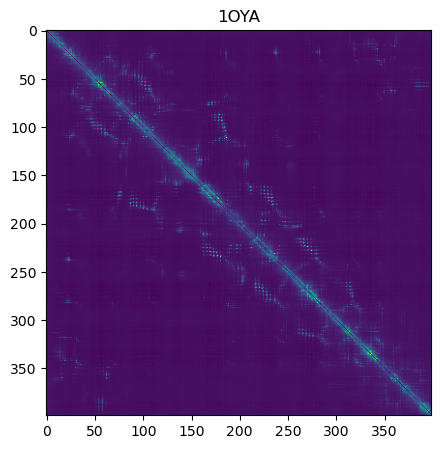

In [44]:

plt.figure(figsize=(10,5))
plt.title(f"{PDB_ID}")
plt.imshow(get_contacts(jac))

plt.savefig(f"{PDB_ID}_catjac_ESM_650M.png", dpi=300, bbox_inches="tight")
plt.show()

TypeError: Invalid shape (390, 20, 390, 20) for image data

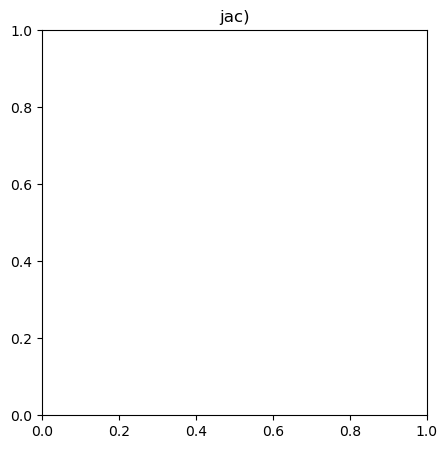

In [27]:
plt.figure(figsize=(10,5))
plt.title("jac)")
plt.imshow(jac)
plt.show()